In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
data = pd.read_csv("weather.csv")

In [22]:
### Data Cleaning

In [8]:
data.drop(
    columns=[
        "Date",
        "Events",
        "SeaLevelPressureHighInches",
        "SeaLevelPressureLowInches"
    ],
    inplace=True
)

In [9]:
data.replace("T", 0.0, inplace=True)
data.replace("-", np.nan, inplace=True)

In [10]:
data = data.apply(pd.to_numeric)

In [11]:
data.fillna(data.mean(), inplace=True)

In [12]:
data.to_csv("weather_final.csv", index=False) #Final csv generated
print("Cleaned dataset saved successfully.\n")

Cleaned dataset saved successfully.



In [13]:
data = pd.read_csv("weather_final.csv")
# Features and Target
X = data.drop(columns=["PrecipitationSumInches"])
Y = data["PrecipitationSumInches"]

In [14]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [15]:
#Train Model
model = LinearRegression()
model.fit(X_train, Y_train)
predictions = model.predict(X_test)

In [16]:
print("R² Score :", r2_score(Y_test, predictions))
print("MSE      :", mean_squared_error(Y_test, predictions))

R² Score : 0.0773403586411261
MSE      : 0.10948811273990036


In [18]:
data

,TempHighF,TempAvgF,TempLowF,DewPointHighF,DewPointAvgF,DewPointLowF,HumidityHighPercent,HumidityAvgPercent,HumidityLowPercent,SeaLevelPressureAvgInches,VisibilityHighMiles,VisibilityAvgMiles,VisibilityLowMiles,WindHighMPH,WindAvgMPH,WindGustMPH,PrecipitationSumInches
0,74,60,45,67.0,49.0,43.0,93.0,75.0,57.0,29.68,10.0,7.0,2.0,20.0,4.0,31.0,0.46
1,56,48,39,43.0,36.0,28.0,93.0,68.0,43.0,30.13,10.0,10.0,5.0,16.0,6.0,25.0,0.00
2,58,45,32,31.0,27.0,23.0,76.0,52.0,27.0,30.49,10.0,10.0,10.0,8.0,3.0,12.0,0.00
3,61,46,31,36.0,28.0,21.0,89.0,56.0,22.0,30.45,10.0,10.0,7.0,12.0,4.0,20.0,0.00
4,58,50,41,44.0,40.0,36.0,86.0,71.0,56.0,30.33,10.0,10.0,7.0,10.0,2.0,16.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1314,103,89,75,71.0,67.0,61.0,82.0,54.0,25.0,29.97,10.0,10.0,10.0,12.0,5.0,21.0,0.00
1315,105,91,76,71.0,64.0,55.0,87.0,54.0,20.0,29.90,10.0,10.0,10.0,14.0,5.0,20.0,0.00
1316,107,92,77,72.0,64.0,55.0,82.0,51.0,19.0,29.86,10.0,10.0,10.0,12.0,4.0,17.0,0.00
1317,106,93,79,70.0,68.0,63.0,69.0,48.0,27.0,29.91,10.0,10.0,10.0,13.0,4.0,20.0,0.00


In [19]:
#Testing
sample = np.array([74, 60, 45, 67, 49, 43, 33, 45, 57, 29.68, 10, 7, 2, 20, 4, 31]).reshape(1, -1)
prediction = model.predict(sample)

print("\nPredicted Precipitation:", prediction[0], "inches")


Predicted Precipitation: 1.0148655850024593 inches


C:\Users\yajat\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


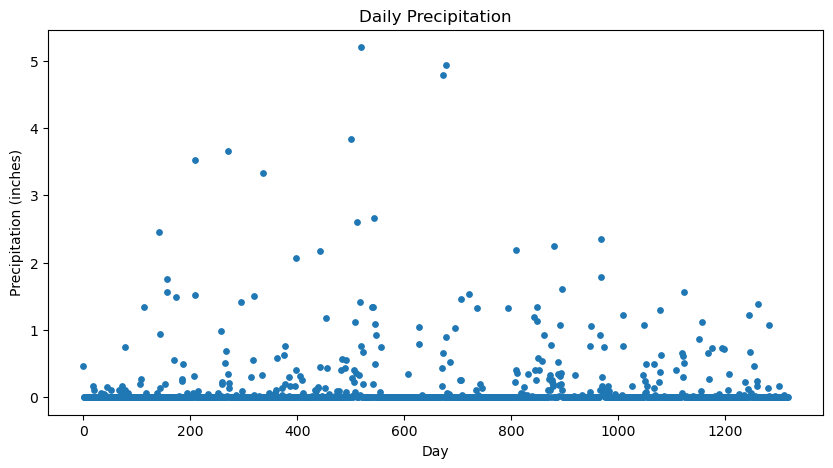

In [20]:
#Graphical representation
plt.figure(figsize=(10,5))
plt.scatter(range(len(Y)), Y, s=15)
plt.title("Daily Precipitation")
plt.xlabel("Day")
plt.ylabel("Precipitation (inches)")
plt.show()

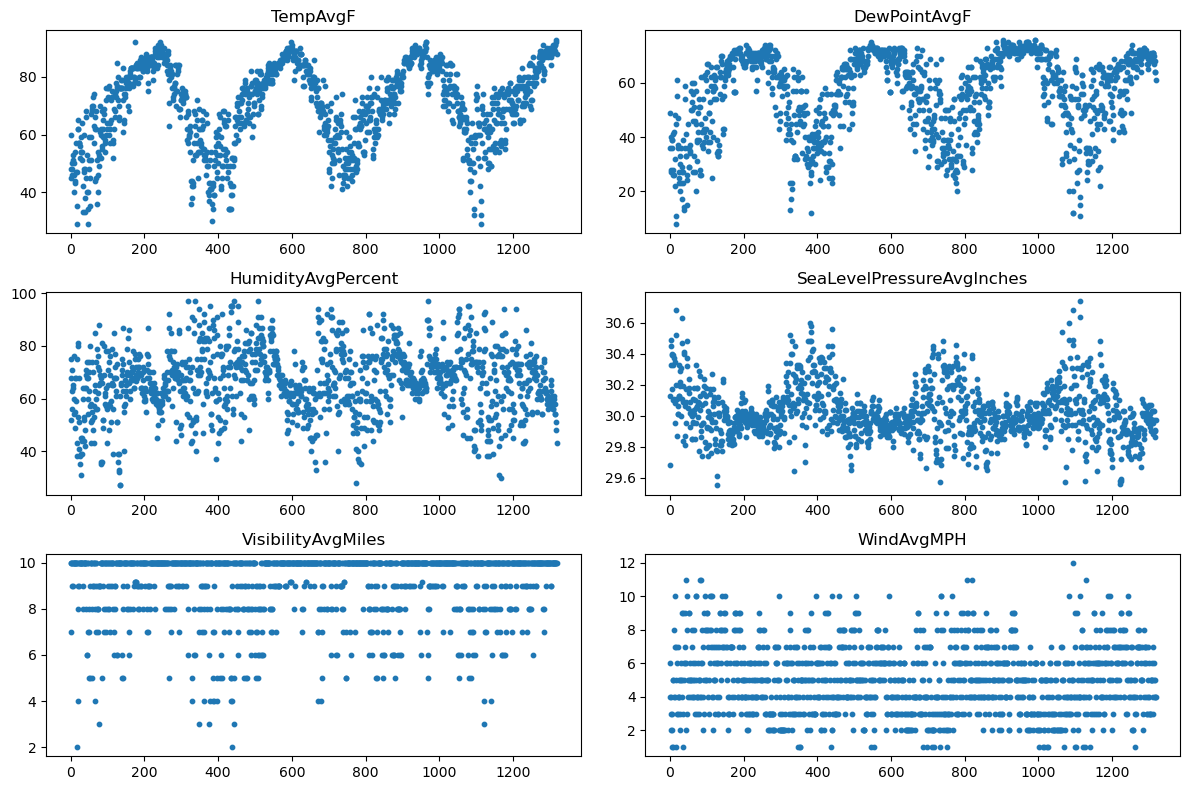

In [21]:
features = [
    "TempAvgF",
    "DewPointAvgF",
    "HumidityAvgPercent",
    "SeaLevelPressureAvgInches",
    "VisibilityAvgMiles",
    "WindAvgMPH"
]

plt.figure(figsize=(12,8))

for i, feature in enumerate(features):
    plt.subplot(3,2,i+1)
    plt.scatter(range(len(data)), data[feature], s=10)
    plt.title(feature)

plt.tight_layout()
plt.show()